## Import

In [1]:
import pandas as pd
df = pd.read_csv('AirPassengers.csv')

In [2]:
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [3]:
df = df.dropna().drop_duplicates()
df = df.rename(columns={'#Passengers': 'Passengers'})
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


# Plot

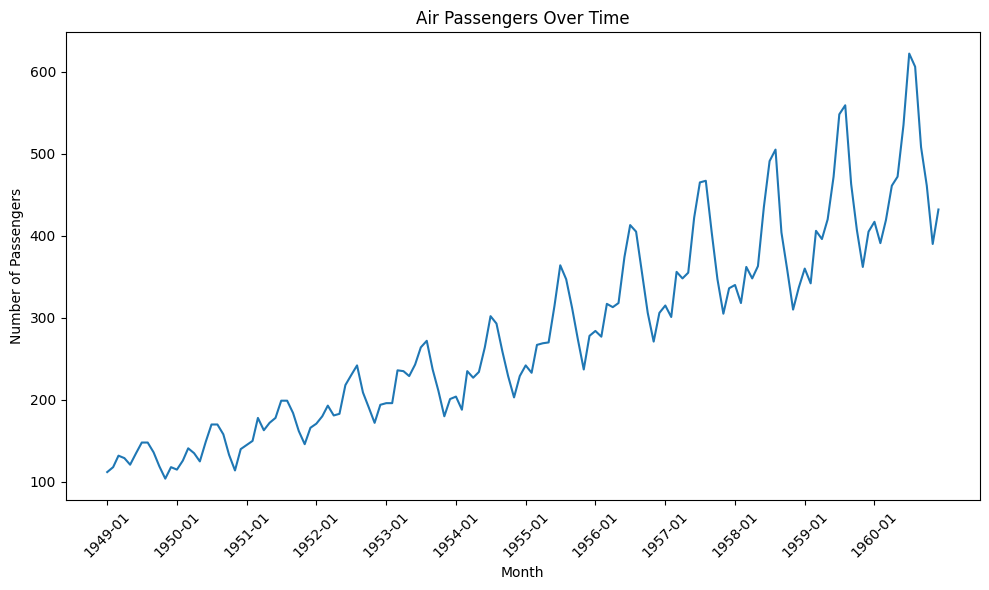

In [4]:
# Yearly Plot 

import matplotlib.pyplot as plt
import pandas as pd
df['Month'] = pd.to_datetime(df['Month'])
plt.figure(figsize=(10, 6))
plt.plot(df['Month'], df['Passengers'])
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.title('Air Passengers Over Time')
plt.xticks(df['Month'][::12], df['Month'][::12].dt.strftime('%Y-%m'), rotation=45)
plt.tight_layout()
plt.show()



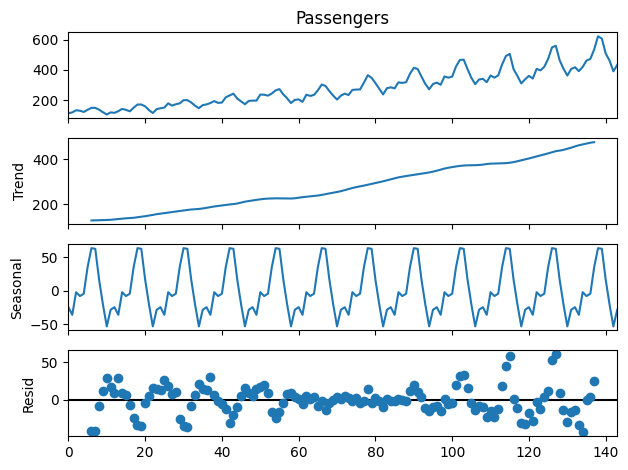

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Passengers'], model='additive', period=12) # 12 Months
result.plot()
plt.show()

## Is It Stationary? Is it autocorrelated?

Stationarity: If P-Value is less than 0.05 & ADF Statistic has a low negative value then it is stationary. If not apply transformation

Autocorrelation: Values have to be below the shaded reigon

In [6]:
from statsmodels.tsa.stattools import adfuller
ADF_result = adfuller(df['Passengers'])
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: 0.8153688792060472
p-value: 0.991880243437641


Transformation is needed

In [7]:
import numpy as np
bandwidth_diff = np.diff(df['Passengers'], n = 1) # n=1 because we want to take the first difference

Test stationarity again

In [8]:
ADF_result = adfuller(bandwidth_diff)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -2.8292668241700056
p-value: 0.054213290283824704


ADF Statistic is -2.82 which isn't a high negative value. P-Value is 0.054 which isn't far off. But just in case we will apply transformation one more time.

In [9]:
second_diff = np.diff(bandwidth_diff, n=1)

In [10]:
ADF_result = adfuller(second_diff)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -16.384231542468495
p-value: 2.7328918500143186e-29


Now that its stationary, lets check for autocorrelation

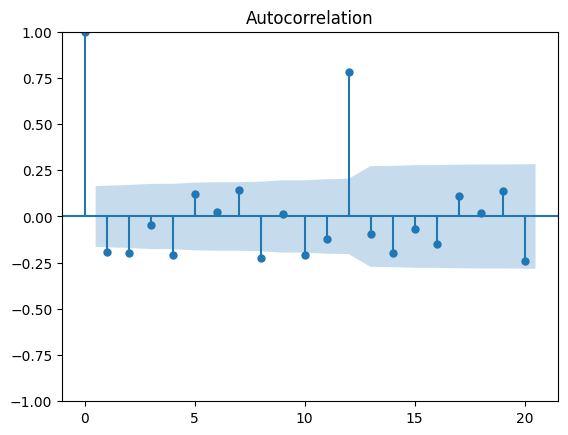

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(second_diff, lags=20);

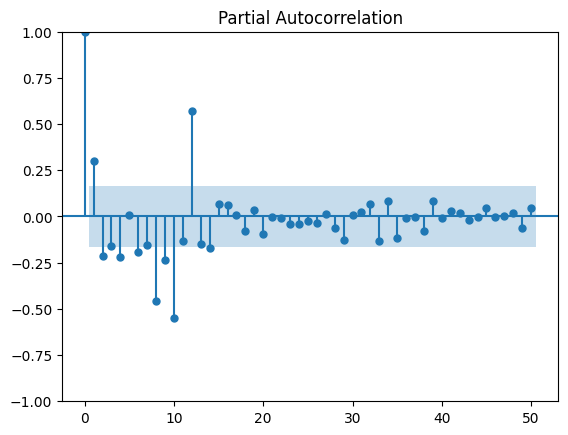

In [12]:
plot_pacf(bandwidth_diff, lags=50);

Since most points are under the shaded reigon. It means most likely they are uncorrelated. But there are some points that are above the shaded reigon. which means its not STRONGLY uncorrelated

# Calculating AIC

First split the dataset. since we have 144 recordings we'll split it in half

In [14]:
result = 144/2
print("Split Dataset:", result)
df_diff = pd.DataFrame({'Transformed Difference': second_diff})
train = df_diff[:-72]
test = df_diff[-72:]

Split Dataset: 72.0


In [16]:
from itertools import product
ps = range(0, 4)
qs = range(0, 4)
d = 2  # because we transformed twice

In [19]:
order_list = list(product(ps, qs))
order_list

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
results = []
for p, q in order_list:
    try:
        model = SARIMAX(train, order=(p, d, q)).fit(disp=False)
        aic = model.aic
        results.append([(p, d, q), aic])
    except:
        continue

/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters 

In [21]:
result_df = pd.DataFrame(results, columns=['(p,d,q)', 'AIC'])
result_df = result_df.sort_values('AIC').reset_index(drop=True)
print(result_df)

      (p,d,q)         AIC
0   (0, 2, 3)  631.919359
1   (2, 2, 2)  644.146616
2   (1, 2, 2)  646.144385
3   (3, 2, 3)  646.854894
4   (2, 2, 3)  647.247865
5   (0, 2, 2)  649.010212
6   (1, 2, 3)  651.806005
7   (3, 2, 1)  667.440161
8   (2, 2, 1)  668.477453
9   (3, 2, 2)  671.165560
10  (1, 2, 1)  679.961495
11  (3, 2, 0)  697.951722
12  (0, 2, 1)  701.216900
13  (2, 2, 0)  704.843077
14  (1, 2, 0)  732.137231
15  (0, 2, 0)  770.974198


Now that our lowest AIC value has p,d,q values 0,2,3 respectively, we can compute residual analysis:
- QQ Plot
- Ljung Box

In [23]:
model = SARIMAX(train, order=(0,2,3)).fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.72850D+00    |proj g|=  1.52197D+00

At iterate    5    f=  4.84238D+00    |proj g|=  3.79696D-02

At iterate   10    f=  4.47088D+00    |proj g|=  1.08588D-02

At iterate   15    f=  4.46606D+00    |proj g|=  1.49575D-03

At iterate   20    f=  4.45665D+00    |proj g|=  4.94468D-04

At iterate   25    f=  4.45660D+00    |proj g|=  1.84744D-04

At iterate   30    f=  4.45657D+00    |proj g|=  5.51525D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nac

/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
 This problem is unconstrained.

   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


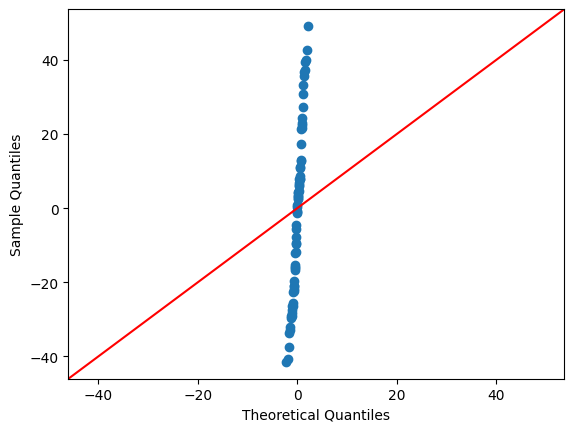

In [25]:
residuals = model.resid
from statsmodels.graphics.gofplots import qqplot

qqplot(residuals, line='45');

LJUNG BOX

In [27]:
from statsmodels.stats.diagnostic import acorr_ljungbox

x = acorr_ljungbox(residuals, lags = [5])

x.iloc[0]

lb_stat      12.068966
lb_pvalue     0.033855
Name: 5, dtype: float64

From this result this means that residuals are autocorrelated. Since the value is 0.033 which is less than 0.05. The model should be discarded. Lets try a different AIC Value

In [30]:
model2 = SARIMAX(train, order=(2,2,2)).fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.51367D+00    |proj g|=  1.53492D+00

At iterate    5    f=  4.76936D+00    |proj g|=  1.64264D-02

At iterate   10    f=  4.76229D+00    |proj g|=  4.47038D-03

At iterate   15    f=  4.71826D+00    |proj g|=  1.56714D-01

At iterate   20    f=  4.60857D+00    |proj g|=  3.69806D-02

At iterate   25    f=  4.54045D+00    |proj g|=  3.71006D-02

At iterate   30    f=  4.53015D+00    |proj g|=  2.94207D-04

At iterate   35    f=  4.53001D+00    |proj g|=  3.96279D-03

At iterate   40    f=  4.52969D+00    |proj g|=  1.22286D-03

At iterate   45    f=  4.52963D+00    |proj g|=  2.84916D-04

At iterate   50    f=  4.52962D+00    |proj g|=  1.41085D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
 This problem is unconstrained.
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


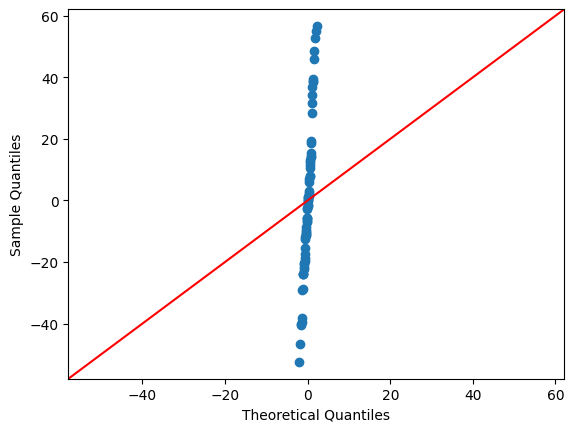

In [31]:
residuals = model2.resid
from statsmodels.graphics.gofplots import qqplot

qqplot(residuals, line='45');

In [32]:
from statsmodels.stats.diagnostic import acorr_ljungbox

x = acorr_ljungbox(residuals, lags = [5])

x.iloc[0]

lb_stat      10.426968
lb_pvalue     0.064003
Name: 5, dtype: float64

From these results. Our Ljung result is ok as its above 0.05 but our graph shows that the values aren't close to x = y. therefore we can try other p,q values

In [33]:
model3 = SARIMAX(train, order=(1,2,2)).fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.32224D+00    |proj g|=  7.58497D-01

At iterate    5    f=  4.69600D+00    |proj g|=  2.45047D-02

At iterate   10    f=  4.57796D+00    |proj g|=  1.30285D-01

At iterate   15    f=  4.55892D+00    |proj g|=  3.05194D-04

At iterate   20    f=  4.55837D+00    |proj g|=  2.24324D-03

At iterate   25    f=  4.55820D+00    |proj g|=  1.70247D-03

At iterate   30    f=  4.55818D+00    |proj g|=  2.02979D-05

At iterate   35    f=  4.55817D+00    |proj g|=  2.52782D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function 

/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
 This problem is unconstrained.


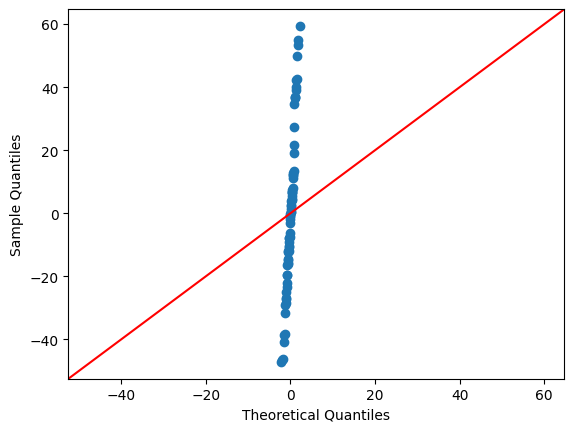

In [34]:
residuals = model3.resid
from statsmodels.graphics.gofplots import qqplot

qqplot(residuals, line='45');

In [35]:
from statsmodels.stats.diagnostic import acorr_ljungbox

x = acorr_ljungbox(residuals, lags = [5])

x.iloc[0]

lb_stat      9.725096
lb_pvalue    0.083410
Name: 5, dtype: float64

Since the QQ plot doesn't improve and we should always stick to the lowest AIC value we will stick to model 2. (2,2,2) & lb_value = 0.06 which is just above 0.05

# Compute MSE

First, split dataset to 75, 25 respectively

In [42]:
train = df_diff[:int(0.75*len(df_diff))]
test = df_diff[int(0.75*len(df_diff)):]

print(len(train))
print(len(test))


106
36


In [60]:
model4 = SARIMAX(train, order=(2,2,2)).fit(disp=False)

/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [61]:
forecast = model4.forecast(steps=len(test))

In [62]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test, forecast)
print(f"MSE: {mse:.2f}")

MSE: 3326.93


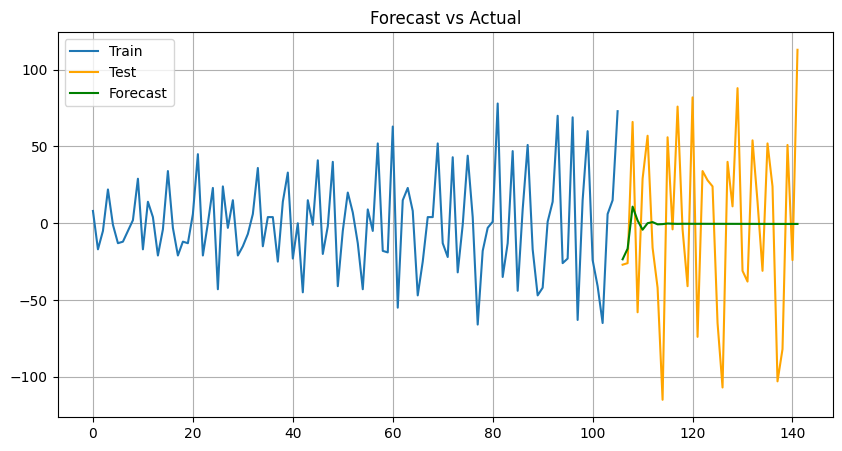

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()


The results are very bad. therefore instead of choosing the previous p,q,d values, let's try the best AIC value from the after splitting dataset to 75-25

In [64]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
results = []
for p, q in order_list:
    try:
        model = SARIMAX(train, order=(p, d, q)).fit(disp=False)
        aic = model.aic
        results.append([(p, d, q), aic])
    except:
        continue

/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/

In [65]:
result_df = pd.DataFrame(results, columns=['(p,d,q)', 'AIC'])
result_df = result_df.sort_values('AIC').reset_index(drop=True)
print(result_df)

      (p,d,q)          AIC
0   (0, 2, 3)  1011.920924
1   (2, 2, 2)  1022.911451
2   (3, 2, 3)  1024.876605
3   (2, 2, 3)  1025.253171
4   (1, 2, 2)  1030.113938
5   (1, 2, 3)  1030.798211
6   (0, 2, 2)  1031.453048
7   (2, 2, 1)  1060.203745
8   (3, 2, 1)  1060.745907
9   (3, 2, 2)  1060.910465
10  (1, 2, 1)  1085.003397
11  (3, 2, 0)  1106.675578
12  (0, 2, 1)  1108.422067
13  (2, 2, 0)  1112.677000
14  (1, 2, 0)  1167.560940
15  (0, 2, 0)  1213.326284


Here we see that the AIC values have changed since our data was split differently however the p,q,d haven't changed. regardless lets see if this changes forecasting results

In [66]:
model5 = SARIMAX(train, order=(0,2,3)).fit(disp=False)

/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [67]:
forecast = model5.forecast(steps=len(test))

In [68]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test, forecast)
print(f"MSE: {mse:.2f}")

MSE: 3369.87


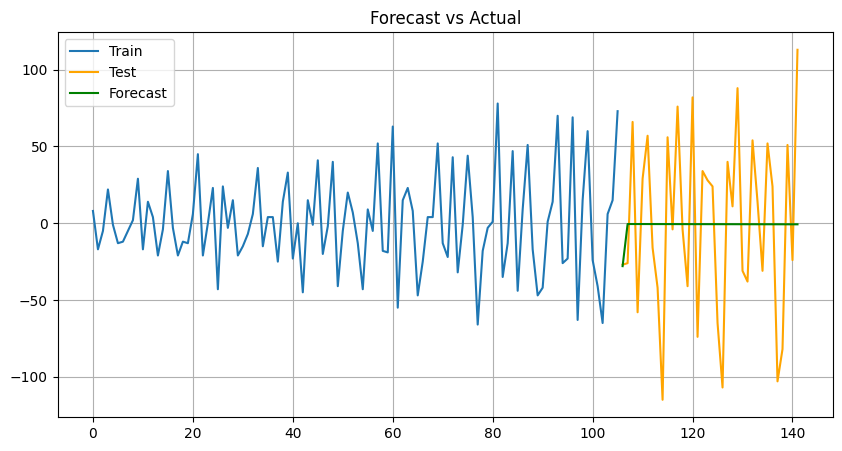

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()

Its worse lol

# LSTM

First we will get the data ready

In [ ]:
data = df['Passengers'].values.reshape(-1, 1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Scale between 0 and 1
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [73]:
train_size = int(len(scaled_data) * 0.75)
train_scaled = scaled_data[:train_size]
test_scaled = scaled_data[train_size:]

In [74]:
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [83]:
sequence_length = 12 
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

In [84]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

Build LSTM

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=30, verbose=0)


/Users/hamoaster/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Forecast

In [86]:
predicted_scaled = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


Evaluate

In [87]:
y_test_inv = scaler.inverse_transform(y_test)
predicted_inv = scaler.inverse_transform(predicted_scaled)

from sklearn.metrics import mean_squared_error
lstm_mse = mean_squared_error(y_test_inv, predicted_inv)
print(f"LSTM MSE: {lstm_mse:.2f}")


LSTM MSE: 7195.37


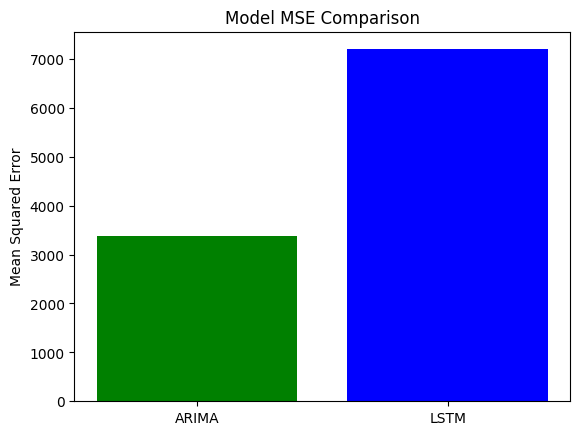

In [88]:
import matplotlib.pyplot as plt

plt.bar(['ARIMA', 'LSTM'], [mse, lstm_mse], color=['green', 'blue'])
plt.title('Model MSE Comparison')
plt.ylabel('Mean Squared Error')
plt.show()